# Importing Necessary Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Creating Dataset

In [11]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Bagging: 
 - Decision Tree
 - Bagging Classifier
 - Random Forest Classifier

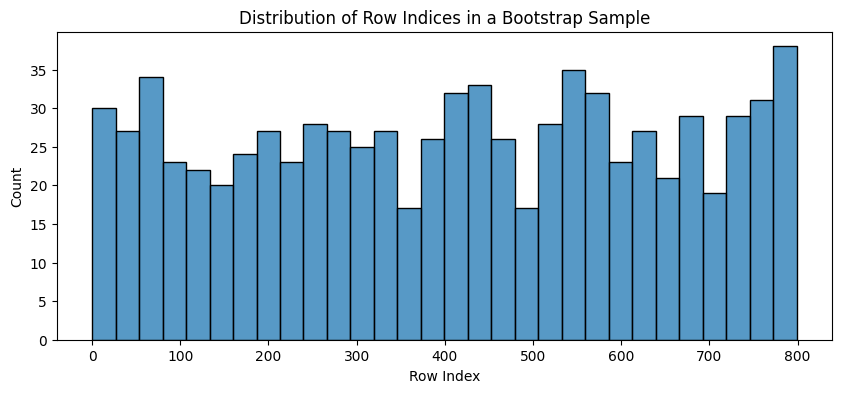

In [12]:
def bootstrap_sample(X, y):
    n = len(X)
    idx = np.random.choice(n, size=n, replace=True)
    return X[idx], y[idx], idx

X_bs, y_bs, idx = bootstrap_sample(X_train, y_train)

plt.figure(figsize=(10,4))
sns.histplot(idx, bins=30, kde=False)
plt.title("Distribution of Row Indices in a Bootstrap Sample")
plt.xlabel("Row Index")
plt.ylabel("Count")
plt.show()

In [13]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, pred_tree)

acc_tree

0.895

In [20]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    bootstrap=True,
    oob_score=True,
    random_state=42
)

bag.fit(X_train, y_train)
print("OOB Score:", bag.oob_score_)
pred_bag = bag.predict(X_test)
acc_bag = accuracy_score(y_test, pred_bag)

acc_bag

OOB Score: 0.92125


0.965

In [15]:
print("Single Decision Tree Accuracy:", acc_tree)
print("Bagging Accuracy:", acc_bag)

Single Decision Tree Accuracy: 0.895
Bagging Accuracy: 0.965


In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)

rf.fit(X_train, y_train)
print("OOB Score:", rf.oob_score_)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

acc_rf

OOB Score: 0.93


0.95

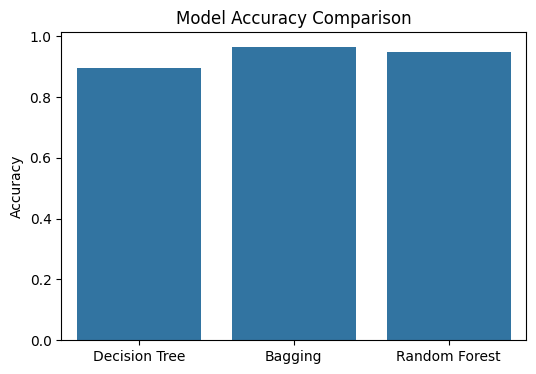

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=["Decision Tree", "Bagging", "Random Forest"],
    y=[acc_tree, acc_bag, acc_rf]
)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Boosting
 - Gradient Boosting
 - XGBoost
 - LightGBM
 - CatBoost
 - AdaBoost

In [23]:
# Base weak learner
base_tree = DecisionTreeClassifier(max_depth=1)  # stump

# Boosting model
ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train, y_train)

# Predictions
pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test, pred_ada)

acc_ada


0.86

In [24]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, pred_gb)

acc_gb


0.955

In [26]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, pred_xgb)

acc_xgb


0.955

In [29]:
lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_train, y_train)

pred_lgb = lgb.predict(X_test)
acc_lgb = accuracy_score(y_test, pred_lgb)

acc_lgb


[LightGBM] [Info] Number of positive: 415, number of negative: 385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.518750 -> initscore=0.075035
[LightGBM] [Info] Start training from score 0.075035
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\ankit\anaconda3\envs\the-learning-curve-labs\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.945

In [31]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

pred_cat = cat.predict(X_test)
acc_cat = accuracy_score(y_test, pred_cat)

acc_cat


0.97

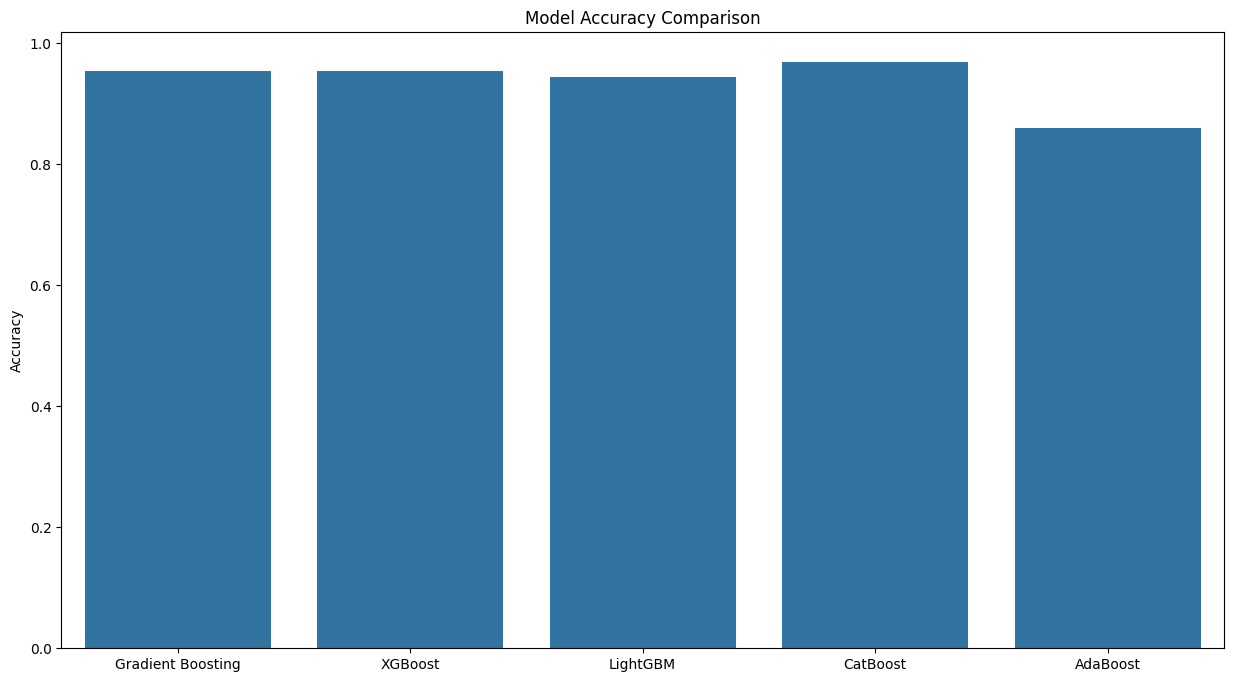

In [35]:
plt.figure(figsize=(15,8))
sns.barplot(
    x=[ "Gradient Boosting", "XGBoost", "LightGBM", "CatBoost","AdaBoost"],
    y=[acc_gb, acc_xgb, acc_lgb, acc_cat, acc_ada]
)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Stacking
 Base models
Each model learns different patterns:
- Logistic Regression → linear patterns
- Random Forest → nonlinear splits
- Gradient Boosting → sequential corrections
- Meta‑model
Learns how to combine the strengths of all base models.
- cv=5
Uses 5‑fold cross‑validation to generate unbiased predictions for stacking.
- acc_stack
 final stacked model accuracy


In [41]:
# Base models (level-0)
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42))
]

# Meta-model (level-1)
meta_model = LogisticRegression()

# Stacking model
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    passthrough=False,   # Only use predictions of base models
    cv=5                 # 5-fold stacking
)

# Train
stack.fit(X_train, y_train)

# Predict
pred_stack = stack.predict(X_test)
acc_stack = accuracy_score(y_test, pred_stack)

acc_stack


0.965